<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi04/blob/main/CNN_BT04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

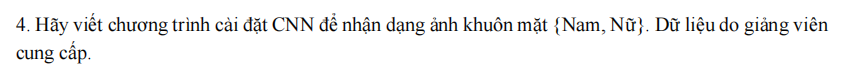

In [1]:
!pip install kagglehub -q

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("cashutosh/gender-classification-dataset")
print("Dataset path:", path)
print(os.listdir(path))

100%|██████████| 269M/269M [00:01<00:00, 163MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/cashutosh/gender-classification-dataset/versions/1
['Validation', 'Training']


In [3]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
##Xóa ảnh bị lỗi
def clean_corrupt_images(folder):
    removed = 0
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            os.remove(fpath)
            removed += 1
    print(f"{os.path.basename(folder)}: xóa {removed} ảnh lỗi")

TRAIN_DIR = os.path.join(path, 'Training')
VAL_DIR  = os.path.join(path, 'Validation') # Changed from TEST_DIR to VAL_DIR and 'Test' to 'Validation'

for cls in ['female', 'male']:
    clean_corrupt_images(os.path.join(TRAIN_DIR, cls))
    clean_corrupt_images(os.path.join(VAL_DIR,  cls)) # Changed to VAL_DIR

female: xóa 0 ảnh lỗi
female: xóa 0 ảnh lỗi
male: xóa 0 ảnh lỗi
male: xóa 0 ảnh lỗi


In [9]:
# Khác MNIST (CSV), bài này đọc ảnh trực tiếp từ thư mục
IMG_SIZE   = (64, 64)   # resize tất cả ảnh về 64×64 pixel
BATCH_SIZE = 32

# Train: tăng cường dữ liệu (augmentation) để model học tổng quát hơn
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixel [0,255] → [0,1]
    shear_range=0.2,          # biến dạng nghiêng ngẫu nhiên
    zoom_range=0.2,           # phóng to/thu nhỏ ngẫu nhiên
    horizontal_flip=True,     # lật ngang ngẫu nhiên
    validation_split=0.1      # tách 10% data train làm validation
)

# Test/Val: chỉ normalize, KHÔNG augment
test_datagen = ImageDataGenerator(rescale=1./255)

# Generator train: 90% của TRAIN_DIR
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',      # 2 lớp → binary (female=0, male=1)
    subset='training'
)

# Generator validation: 10% còn lại của TRAIN_DIR
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Generator test: dùng thư mục Validation làm tập test cuối
test_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False             # KHÔNG xáo trộn để đánh giá đúng thứ tự
)

print("Class indices:", train_generator.class_indices)  # {'female':0, 'male':1}
print("Train:", train_generator.samples)   # ~42309 ảnh
print("Val:  ", val_generator.samples)     # ~4700 ảnh
print("Test: ", test_generator.samples)    # ~11649 ảnh

Found 42309 images belonging to 2 classes.
Found 4700 images belonging to 2 classes.
Found 11649 images belonging to 2 classes.
Class indices: {'female': 0, 'male': 1}
Train: 42309
Val:   4700
Test:  11649


In [10]:
##Build CNN

# Ảnh màu RGB → input_shape=(64,64,3) khác MNIST grayscale (28,28,1)
input_shape = (64, 64, 3)

model = Sequential()
model.add(keras.Input(shape=input_shape))

# Conv Block 1: học đặc trưng cơ bản (cạnh, màu sắc...)
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
# → output: (62, 62, 32)
model.add(MaxPool2D(pool_size=(2,2)))
# → output: (31, 31, 32) — giảm kích thước ÷2

# Conv Block 2: học đặc trưng phức tạp hơn
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
# → output: (29, 29, 64)
model.add(MaxPool2D(pool_size=(2,2)))
# → output: (14, 14, 64)

# Conv Block 3: học đặc trưng trừu tượng (cần thêm 1 block vì ảnh khuôn mặt phức tạp)
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
# → output: (12, 12, 128)
model.add(MaxPool2D(pool_size=(2,2)))
# → output: (6, 6, 128)

# Fully Connected
model.add(Flatten())
# → output: 4608 (= 6×6×128) — chuyển 3D → 1D

model.add(Dense(128, activation='relu'))  # tầng ẩn 128 neurons
model.add(Dropout(0.5))                   # tắt 50% neuron ngẫu nhiên → tránh overfitting
model.add(Dense(1, activation='sigmoid')) # output 1 neuron → sigmoid vì binary classification
# sigmoid: female=gần 0, male=gần 1

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # loss cho bài toán 2 lớp (binary)
    metrics=['accuracy']
)

model_fit = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,  # theo dõi validation sau mỗi epoch
    verbose=1
)
# Epoch 1: accuracy ~88% → tăng dần lên ~96% ở epoch 15

Epoch 1/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 342s 257ms/step - accuracy: 0.8827 - loss: 0.2778 - val_accuracy: 0.9440 - val_loss: 0.1555
Epoch 2/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 336s 254ms/step - accuracy: 0.9375 - loss: 0.1736 - val_accuracy: 0.9472 - val_loss: 0.1455
Epoch 3/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 347s 262ms/step - accuracy: 0.9436 - loss: 0.1536 - val_accuracy: 0.9532 - val_loss: 0.1282
Epoch 4/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 333s 252ms/step - accuracy: 0.9494 - loss: 0.1440 - val_accuracy: 0.9540 - val_loss: 0.1311
Epoch 5/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 335s 253ms/step - accuracy: 0.9518 - loss: 0.1394 - val_accuracy: 0.9596 - val_loss: 0.1148
Epoch 6/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 332s 251ms/step - accuracy: 0.9521 - loss: 0.1372 - val_accuracy: 0.9613 - val_loss: 0.1142
Epoch 7/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 336s 254ms/step - accuracy: 0.9546 - loss: 0.1287 - val_accuracy: 0.9609 - val_loss: 0.1161
Epoch 8/15
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 334s 253ms/step - ac

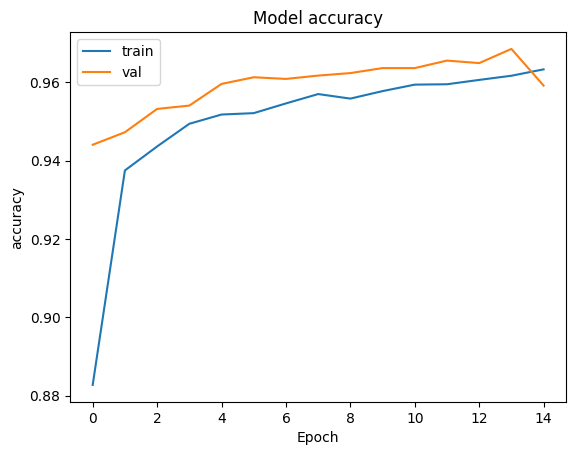

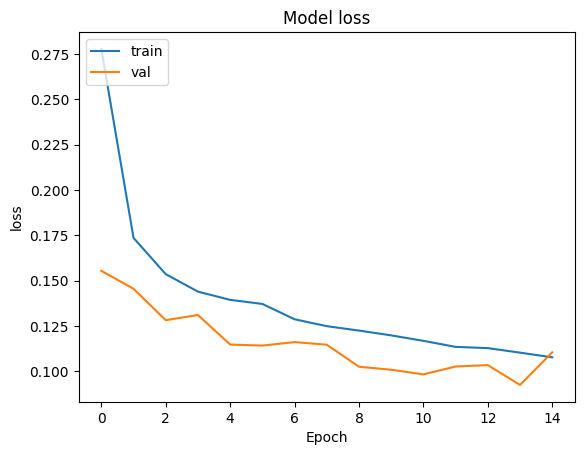

In [12]:
##Biểu đồ

for metric in ['accuracy', 'loss']:
    plt.plot(model_fit.history[metric])
    plt.plot(model_fit.history[f'val_{metric}'])
    plt.title(f'Model {metric}')
    plt.ylabel(metric)
    plt.xlabel('Epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()

In [13]:
##Đánh giá trên tập Test

score = model.evaluate(test_generator, verbose=2)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

365/365 - 23s - 64ms/step - accuracy: 0.9682 - loss: 0.0907
Test loss:     0.09066101908683777
Test accuracy: 0.9682376384735107


Upload ảnh khuôn mặt (jpg/png, tối đa 20):


Saving man_lọnghair.jpg to man_lọnghair.jpg
Saving men.jpg to men.jpg
[1] man_lọnghair.jpg               → male (99.99%)
[2] men.jpg                        → male (88.16%)


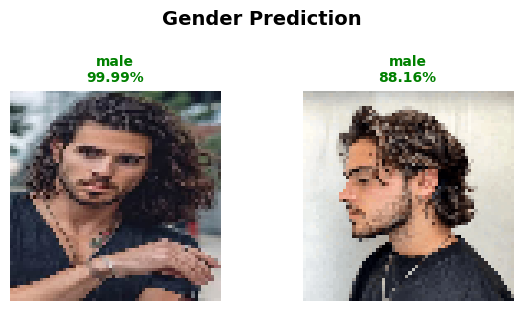

In [15]:
from google.colab import files
from keras.preprocessing import image

def predict_gender():
    print("Upload ảnh khuôn mặt (jpg/png, tối đa 20):")
    uploaded = files.upload()

    valid = {k: v for k, v in uploaded.items()
             if k.lower().endswith(('.jpg', '.jpeg', '.png'))}

    if not valid:
        print("Không có ảnh hợp lệ.")
        return

    if len(valid) > 20:
        valid = dict(list(valid.items())[:20])

    n    = len(valid)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))

    if n == 1:   axes = np.array([[axes]])
    elif rows==1: axes = axes.reshape(1, -1)
    elif cols==1: axes = axes.reshape(-1, 1)

    class_names = {v: k for k, v in train_generator.class_indices.items()}

    for idx, (fname, _) in enumerate(valid.items()):
        r, c  = divmod(idx, cols)
        ax    = axes[r][c]

        img        = image.load_img(fname, target_size=IMG_SIZE)
        img_arr    = image.img_to_array(img) / 255.0
        img_input  = np.expand_dims(img_arr, axis=0)

        pred       = model.predict(img_input, verbose=0)[0][0]
        label_idx  = 1 if pred > 0.5 else 0
        label      = class_names[label_idx]
        confidence = pred if pred > 0.5 else 1 - pred
        color      = 'green' if confidence >= 0.7 else 'orange'

        ax.imshow(img)
        ax.set_title(f'{label}\n{confidence:.2%}',
                     color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        print(f"[{idx+1}] {fname:30s} → {label} ({confidence:.2%})")

    for idx in range(n, rows*cols):
        r, c = divmod(idx, cols)
        axes[r][c].axis('off')

    plt.suptitle('Gender Prediction', fontsize=14,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    for fname in valid:
        if os.path.exists(fname): os.remove(fname)

predict_gender()

In [17]:
model.save_weights('gender_cnn.weights.h5')
model.save('gender_model.keras')